# Amsterdam Co-Accessibility with CBS Population Data

This notebook tells a simple story with **one public-space type: parks and public squares**.

The question is: **Which parks and public squares can be seen as nice opportunities for potential intergenerational encounters?**

We estimate this by asking which age groups have walkable access to each public space. A public space with walkable access for children, adults, and older adults can be interpreted as a stronger opportunity for potential intergenerational encounters.


In [1]:
import accessx as acx
import geopandas as gpd
import math
import matplotlib.pyplot as plt
import osmnx as ox
import pandas as pd
from pathlib import Path


## Setup


In [2]:
epsg_ams = 28992
resolution = 9
buffer_m = 1000
max_cost = 15
cost_attr = "avg_time"

coacc_path = Path("../data/case_studies/coaccessibility/amsterdam")
area_path = coacc_path / "area"
population_path = coacc_path / "population"
street_network_path = coacc_path / "street_network"
pois_path = coacc_path / "pois"
results_path = coacc_path / "results"

for folder in [coacc_path, area_path, population_path, street_network_path, pois_path, results_path]:
    folder.mkdir(parents=True, exist_ok=True)

cbs_path = Path("../data/nl_cbs/cbs_vk100_2020_vol.gpkg")

population_columns = {
    "population": "aantal_inwoners",
    "children": "aantal_inwoners_0_tot_15_jaar",
    "age_15_25": "aantal_inwoners_15_tot_25_jaar",
    "age_25_45": "aantal_inwoners_25_tot_45_jaar",
    "age_45_65": "aantal_inwoners_45_tot_65_jaar",
    "elderly": "aantal_inwoners_65_jaar_en_ouder",
}

poi_groups = {
    "public_space": {
        "leisure": ["park"],
        "place": ["square"],
    },
}


## 1. Load Amsterdam


In [3]:
gdf_ams = ox.geocode_to_gdf("Amsterdam, Netherlands")
acx.save_gdf(gdf_ams, area_path / "aoi_amsterdam.geojson")
# gdf_ams = acx.read_gdf(area_path / "aoi_amsterdam.geojson")


## 2. Create Hexagons


In [4]:
hex_ams = acx.make_hex_grid(gdf_ams, resolution=resolution, clip=True)
acx.save_gdf(hex_ams, area_path / "hexes_amsterdam.geojson")
# hex_ams = acx.read_gdf(area_path / "hexes_amsterdam.geojson")


## 3. Load the CBS grid and keep only Amsterdam


In [5]:
ams_bbox = tuple(gdf_ams.to_crs(epsg_ams).total_bounds)
cbs_ams = gpd.read_file(cbs_path, bbox=ams_bbox)
cbs_ams = cbs_ams.to_crs(epsg_ams)
cbs_ams = gpd.overlay(
    cbs_ams[["geometry"] + list(population_columns.values())],
    gdf_ams.to_crs(epsg_ams)[["geometry"]],
    how="intersection",
    keep_geom_type=False,
)

for source_col in population_columns.values():
    cbs_ams[source_col] = pd.to_numeric(cbs_ams[source_col], errors="coerce")
    cbs_ams[source_col] = cbs_ams[source_col].where(cbs_ams[source_col] >= 0, 0.0)

cbs_ams = cbs_ams.rename(columns={source: target for target, source in population_columns.items()})
cbs_ams["adults"] = cbs_ams[["age_15_25", "age_25_45", "age_45_65"]].sum(axis=1)

acx.save_gdf(cbs_ams, population_path / "cbs_amsterdam_clipped.geojson")
# cbs_ams = acx.read_gdf(population_path / "cbs_amsterdam_clipped.geojson")

cbs_ams[["population", "children", "adults", "elderly"]].sum()


population    870380
children      122015
adults        628145
elderly       107030
dtype: int64

## 4. Map the CBS population to the hexagons


In [6]:
hex_pop_ams = acx.map_population_grid_to_hexes(
    hex_ams,
    cbs_ams,
    metric_crs=epsg_ams,
    population_cols=["population", "children", "adults", "elderly"],
)
acx.save_gdf(hex_pop_ams, population_path / "hexes_population_amsterdam_cbs.geojson")
# hex_pop_ams = acx.read_gdf(population_path / "hexes_population_amsterdam_cbs.geojson")

hex_pop_ams[["population", "children", "adults", "elderly"]].sum()


population    866984.296558
children      121707.783927
adults        625718.376955
elderly       106808.056219
dtype: float64

## 5. Build the walking network


In [7]:
graph_ams = acx.build_network(
    AOI=gdf_ams,
    city_epsg=epsg_ams,
    buffer_m=buffer_m,
    network_type="walk",
    simplify=False,
    retain_all=True,
)

graph_ams = acx.add_time_cost_constant_speed(
    graph_ams,
    speed_kmh=4.5,
    cost_col=cost_attr,
)

acx.save_graph(
    graph_ams,
    out_dir=street_network_path,
    base_name="amsterdam_graph_with_cost",
    save_nodes=True,
    save_edges=True,
)

# graph_ams = acx.load_graph(
#     nodes_path=street_network_path / "amsterdam_graph_with_cost_nodes_OSM.geojson",
#     edges_path=street_network_path / "amsterdam_graph_with_cost_edges_OSM.geojson",
#     crs=epsg_ams,
# )


## 6. Collect parks and public squares


In [8]:
public_space_pois = acx.get_pois_osm(gdf_ams, poi_groups=poi_groups)
acx.save_gdf(public_space_pois, pois_path / "pois_amsterdam_parks_public_squares.geojson")
# public_space_pois = acx.read_gdf(pois_path / "pois_amsterdam_parks_public_squares.geojson")

public_space_pois.head()


,id,osmid,name,osm_type,category,subcategory,osm_key,osm_value,geometry
0,0,4609693622,Amstelpark,node,public_space,park,leisure,park,POINT (4.89129 52.33224)
1,1,9039126487,Beeldenbos Noord,node,public_space,park,leisure,park,POINT (4.93858 52.38996)
2,2,12669950252,Rhonepark,node,public_space,park,leisure,park,POINT (4.83112 52.38987)
3,3,7350368,Gijsbrecht van Aemstelpark,relation,public_space,park,leisure,park,"MULTIPOLYGON (((4.86927 52.32931, 4.86918 52.3..."
4,4,14035050,Rembrandtpark,relation,public_space,park,leisure,park,"MULTIPOLYGON (((4.84779 52.35606, 4.84781 52.3..."


## 7. Compute co-accessibility for parks and public squares

For each park or public square, we estimate how many children, adults, and older adults have walkable access within 15 minutes.


In [9]:
coacc_public_spaces = acx.compute_co_accessibility(
    graph_ams,
    hex_pop_ams,
    public_space_pois,
    max_cost=max_cost,
    cost_attr=cost_attr,
    population_groups=["children", "adults", "elderly"],
    poi_id_col="id",
    category_col="category",
    keep_poi_cols=["name"],
    approach="cumulative",
)
acx.save_gdf(coacc_public_spaces, results_path / "coaccessibility_parks_public_squares_cumulative.geojson")
# coacc_public_spaces = acx.read_gdf(results_path / "coaccessibility_parks_public_squares_cumulative.geojson")

coacc_public_spaces.head()


,id,geometry,category,name,coacc_children,coacc_adults,coacc_elderly
0,0,POINT (4.89129 52.33224),public_space,Amstelpark,987.896272,5717.029130,2218.819524
1,1,POINT (4.93858 52.38996),public_space,Beeldenbos Noord,399.285204,1686.717329,518.272154
2,2,POINT (4.83112 52.38987),public_space,Rhonepark,0.000000,0.000000,0.000000
3,3,"MULTIPOLYGON (((4.86927 52.32931, 4.86918 52.3...",public_space,Gijsbrecht van Aemstelpark,1671.893932,9376.994137,3285.084264
4,4,"MULTIPOLYGON (((4.84779 52.35606, 4.84781 52.3...",public_space,Rembrandtpark,1949.530397,11556.331711,1528.724154


## 8. Age mix with walkable access to each public space

We calculate Shannon diversity across the three age groups with walkable access to each park or public square:

`H = -sum(p_i * ln(p_i))`

Here, `p_i` is the proportion of the accessible age-group population belonging to each group. The normalized index ranges from `0` to `1`, where higher values mean a more even mix of children, adults, and older adults.


In [10]:
public_space_access = coacc_public_spaces.copy()

age_group_cols = ["coacc_children", "coacc_adults", "coacc_elderly"]
public_space_access["age_group_access"] = public_space_access[age_group_cols].sum(axis=1)
public_space_access["age_diversity_shannon"] = 0.0

mask = public_space_access["age_group_access"] > 0
age_group_proportions = public_space_access.loc[mask, age_group_cols].div(
    public_space_access.loc[mask, "age_group_access"],
    axis=0,
)
public_space_access.loc[mask, "age_diversity_shannon"] = age_group_proportions.apply(
    lambda row: -sum(p * math.log(p) for p in row if p > 0),
    axis=1,
)
public_space_access["age_diversity_shannon_normalized"] = (
    public_space_access["age_diversity_shannon"] / math.log(len(age_group_cols))
)

public_space_access[[
    "name",
    "coacc_children",
    "coacc_adults",
    "coacc_elderly",
    "age_diversity_shannon_normalized",
]].head()


,name,coacc_children,coacc_adults,coacc_elderly,age_diversity_shannon_normalized
0,Amstelpark,987.896272,5717.029130,2218.819524,0.796418
1,Beeldenbos Noord,399.285204,1686.717329,518.272154,0.810222
2,Rhonepark,0.000000,0.000000,0.000000,0.000000
3,Gijsbrecht van Aemstelpark,1671.893932,9376.994137,3285.084264,0.788153
4,Rembrandtpark,1949.530397,11556.331711,1528.724154,0.636772


## 9. Potential intergenerational encounter opportunities

The first three maps show walkable access by age group. The final map shows the age mix: public spaces where access is more evenly shared across children, adults, and older adults.


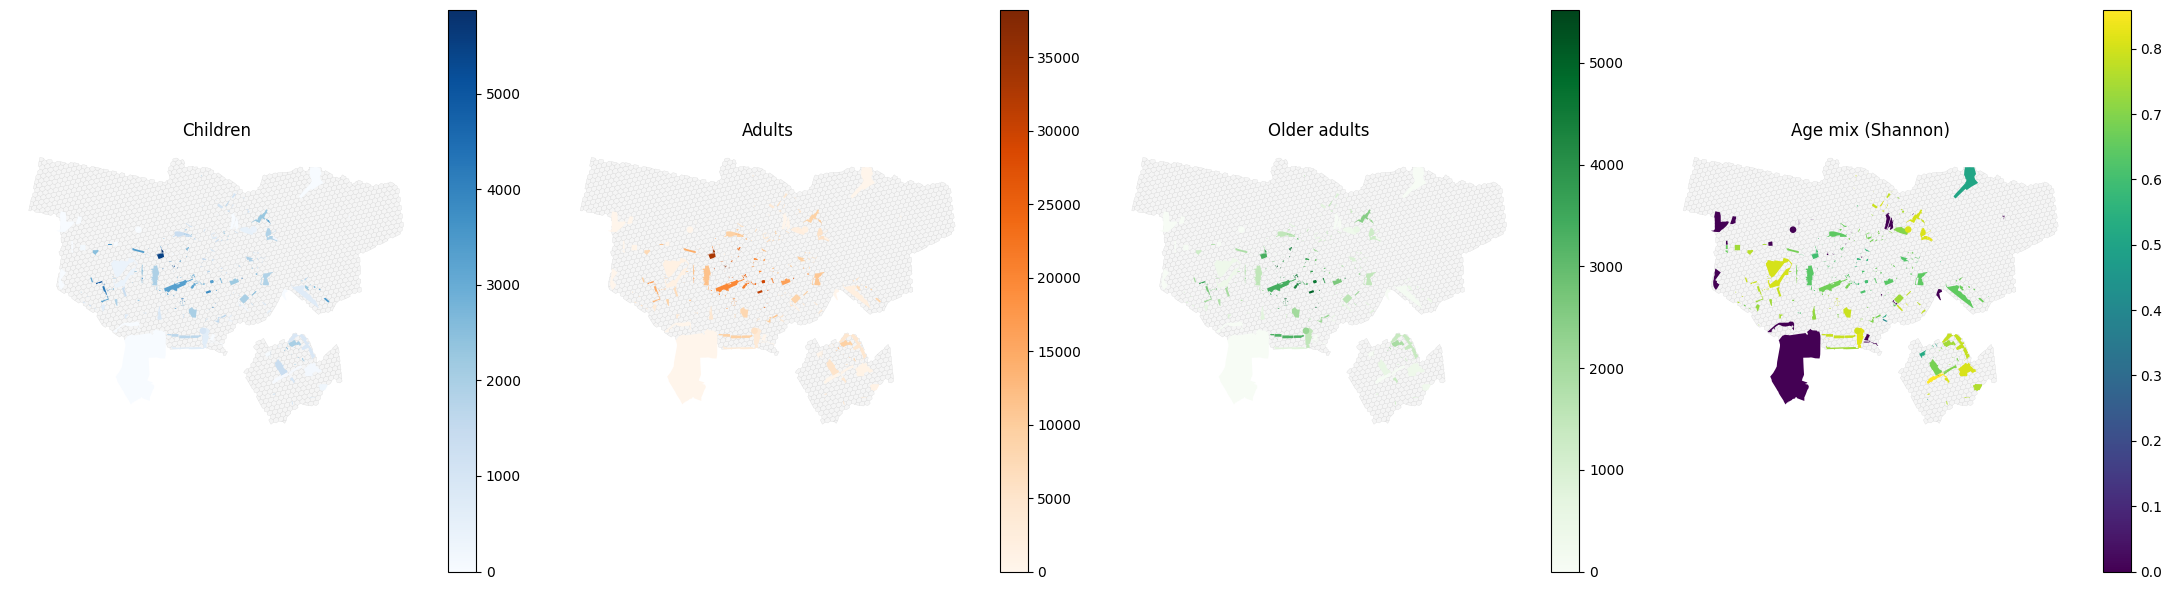

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(22, 6))
map_specs = [
    ("coacc_children", "Blues", "Children"),
    ("coacc_adults", "Oranges", "Adults"),
    ("coacc_elderly", "Greens", "Older adults"),
    ("age_diversity_shannon_normalized", "viridis", "Age mix (Shannon)"),
]

for ax, (column, cmap, title) in zip(axes, map_specs):
    hex_ams.plot(ax=ax, color="whitesmoke", edgecolor="lightgray", linewidth=0.2)
    public_space_access.plot(
        ax=ax,
        column=column,
        cmap=cmap,
        legend=True,
        markersize=14,
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()
